In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
X, y_true = make_blobs(n_samples=500, centers=3, cluster_std = 0.60,
                  random_state=42)

In [6]:
df = pd.DataFrame(X, columns = ['feature_1', 'feature_2'])


In [8]:
df

,feature_1,feature_2
0,-6.190063,-7.302015
1,3.021747,1.940593
2,5.953761,1.488191
3,-2.744463,8.136177
4,5.360607,1.728324
...,...,...
495,-6.040014,-6.325329
496,-2.555459,9.218977
497,4.438408,2.974583
498,-7.193261,-6.250704


In [9]:
scaler  = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [10]:
inertia = []
K_range = range(1, 10)


In [11]:
for k in K_range:
    kmeans = KMeans(n_clusters = k)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

In [12]:
inertia

[1000.0000000000006,
 297.8954141051723,
 11.575484723104985,
 9.754002137433167,
 8.419564892399961,
 6.964287281923282,
 6.342076991846003,
 5.803716748840902,
 5.347570748901195]

Text(0.5, 1.0, 'Elbow Method showing the optimal k')

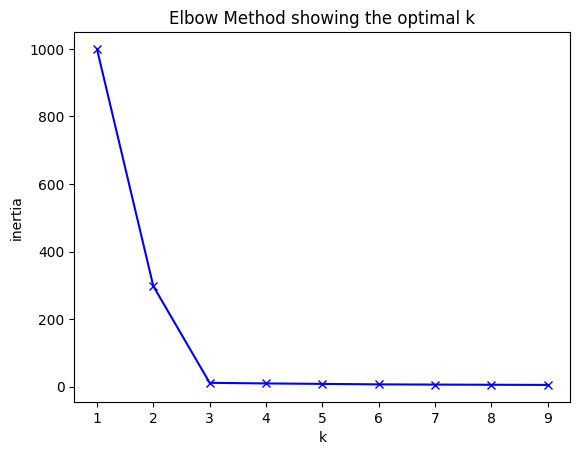

In [13]:
elb = plt.plot(K_range, inertia, 'bx-')
plt.xlabel('k')
plt.ylabel('inertia')
plt.title('Elbow Method showing the optimal k')

In [14]:
kmeans_final = KMeans(n_clusters = 3, random_state=42)
cluster_label = kmeans_final.fit_predict(X_scaled)

In [15]:
df['cluster'] = cluster_label

<Axes: xlabel='feature_1', ylabel='feature_2'>

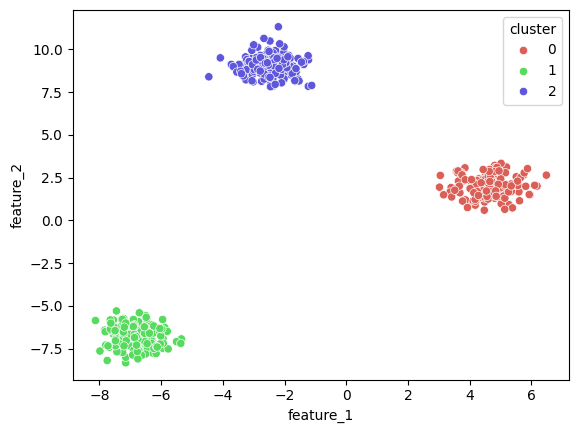

In [16]:
sns.scatterplot(
    x = df['feature_1'],
    y = df['feature_2'],
    hue = df['cluster'],
    palette = sns.color_palette('hls', 3)
)

**DBSCAN**

In [22]:
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN, KMeans

In [21]:
X, y_true = make_moons(n_samples=500, noise = 0.05, random_state=42)

In [23]:
df = pd.DataFrame(X, columns = ['feature_1', 'feature_2'])

In [24]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [25]:
kmeans = KMeans(n_clusters = 2, random_state=42)
kmeans_label = kmeans.fit_predict(X_scaled)


In [26]:
df['kmeans_cluster'] = kmeans_label

<Axes: xlabel='feature_1', ylabel='feature_2'>

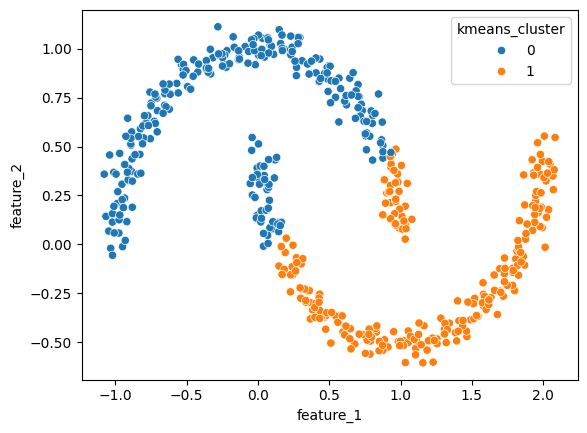

In [27]:
sns.scatterplot(
    x = df['feature_1'],
    y = df['feature_2'],
    hue = df['kmeans_cluster'],
    palette = 'tab10'
)
#

In [28]:
dbscan = DBSCAN(eps = 0.3, min_samples = 5)
dbscan_label = dbscan.fit_predict(X_scaled)

In [29]:
df['dbscan_cluster'] = dbscan_label

<Axes: xlabel='feature_1', ylabel='feature_2'>

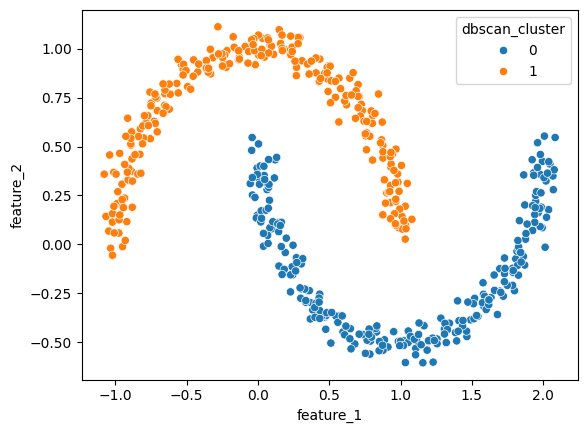

In [30]:
sns.scatterplot(
    x = df['feature_1'],
    y = df['feature_2'],
    hue = df['dbscan_cluster'],
    palette = 'tab10'
)